In [1]:
!git clone https://github.com/spMohanty/PlantVillage-Dataset.git

Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 163235, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 163235 (delta 2), reused 0 (delta 0), pack-reused 163229 (from 1)
Receiving objects: 100% (163235/163235), 2.00 GiB | 27.83 MiB/s, done.
Resolving deltas: 100% (101/101), done.
Updating files: 100% (182401/182401), done.


In [2]:
import tensorflow_datasets as tfds

dataset, info = tfds.load('plant_village', with_info=True)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.IFTNGP_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.


In [3]:
info = tfds.builder("plant_village").info
class_names = info.features['label'].names
class_names


['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry___healthy',
 'Cherry___Powdery_mildew',
 'Corn___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn___Common_rust',
 'Corn___healthy',
 'Corn___Northern_Leaf_Blight',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___healthy',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___healthy',
 'Potato___Late_blight',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___healthy',
 'Strawberry___Leaf_scorch',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___healthy',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomat

In [16]:
label_decoder = info.features['label'].int2str
label_encoder = info.features['label'].str2int


In [ ]:
# STEP 1: Install dependencies (if running in Colab)
!pip install tensorflow-datasets

# STEP 2: Import libraries
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# STEP 3: Load dataset with (image, label) format
dataset, info = tfds.load("plant_village", with_info=True, as_supervised=True)
full_dataset = dataset['train']

# STEP 4: Split dataset manually: 80% train, 10% val, 10% test
total = info.splits['train'].num_examples
train_size = int(0.8 * total)
val_size = int(0.1 * total)

train_dataset = full_dataset.take(train_size)
val_dataset = full_dataset.skip(train_size).take(val_size)
test_dataset = full_dataset.skip(train_size + val_size)

# STEP 5: Preprocessing function
def preprocess(image, label):
    image = tf.image.resize(image, [224, 224])
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

# STEP 6: Prepare data pipelines
batch_size = 32
import tensorflow as tf

# Preprocessing and augmentation function
def preprocess_and_augment(features):
    image = features['image']
    label = features['label']

    # Resize and cast
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(image, tf.float32)

    # Augmentation
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.image.random_saturation(image, 0.8, 1.2)
    image = tf.image.random_hue(image, 0.02)

    # Normalize
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

    return image, label

# Preprocessing for val/test (no augmentation)
def preprocess(features):
    image = features['image']
    label = features['label']
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

# Batch size
batch_size = 32

# Apply preprocessing
train_dataset = train_dataset.map(preprocess_and_augment, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_dataset = val_dataset.map(preprocess).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.map(preprocess).batch(batch_size).prefetch(tf.data.AUTOTUNE)



# STEP 7: Load base model (MobileNetV2)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base model

# STEP 8: Add classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(info.features['label'].num_classes, activation='softmax')(x)

# STEP 9: Build and compile the full model
model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# STEP 10: Train the model
history = model.fit(train_dataset, epochs=5, validation_data=val_dataset)

# Optional: Plot training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.068U9F_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.


TypeError: in user code:


    TypeError: outer_factory.<locals>.inner_factory.<locals>.tf__preprocess_and_augment() takes 1 positional argument but 2 were given


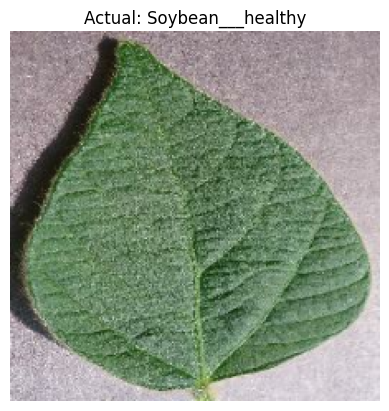

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted: Soybean___healthy


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Load a sample image from test_dataset
for image, label in test_dataset.take(1):
    img = image[0].numpy()
    lbl = label[0].numpy()
    plt.imshow((img + 1) / 2)  # reverse preprocessing
    plt.title(f"Actual: {class_names[lbl]}")
    plt.axis('off')
    plt.show()

    pred = model.predict(tf.expand_dims(image[0], axis=0))
    pred_class = np.argmax(pred)
    print(f"Predicted: {class_names[pred_class]}")


In [9]:
model.save("/content/drive/myDrive/new_plant.h5")

In [12]:
from PIL import Image
import numpy as np

def load_and_prepare_image(image_path):
    img = Image.open(image_path).convert('RGB')
    img = img.resize((224, 224))
    img_array = np.array(img)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
    return np.expand_dims(img_array, axis=0)  # Add batch dimension


In [18]:
# Prepare image
img_input = load_and_prepare_image("/content/Test_tomato_yellow.jpeg")

# Predict
predictions = model.predict(img_input)
predicted_index = np.argmax(predictions[0])
# label_decoder = info.features['label'].int2str
# predicted_label = label_decoder(predicted_index)
predicted_index = np.argmax(predictions[0])
predicted_label = label_decoder(predicted_index)


print(f"Predicted Disease: {predicted_label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted Disease: Strawberry___Leaf_scorch


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━

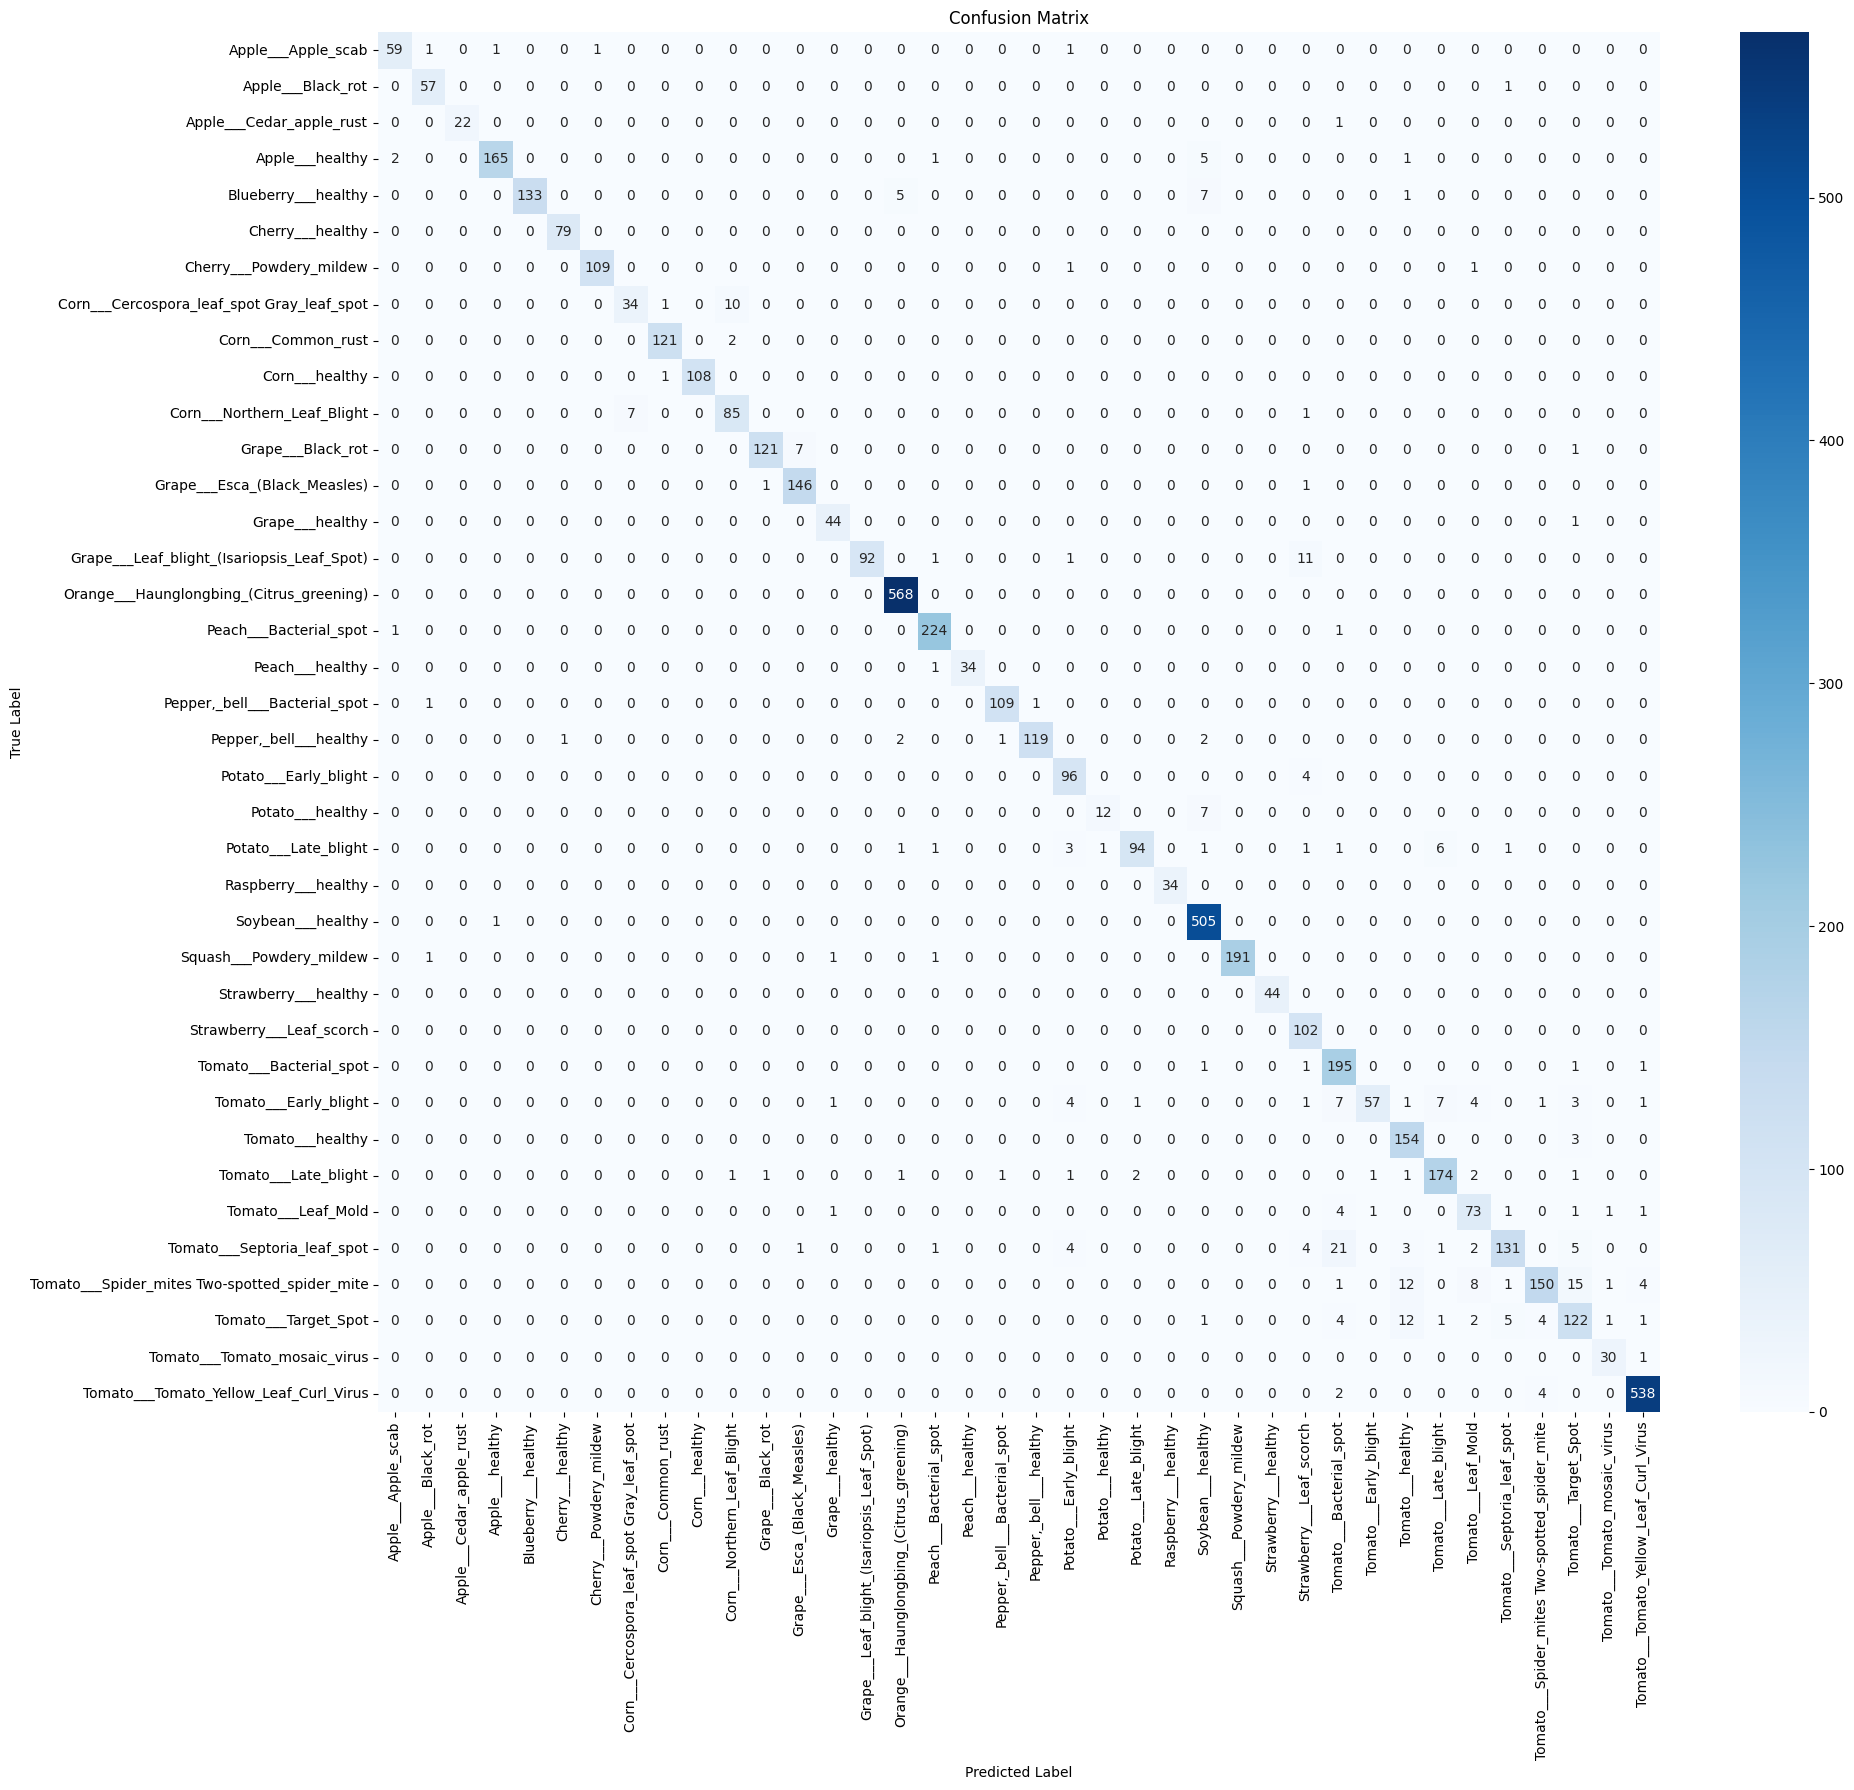


Classification Report:

                                               precision    recall  f1-score   support

                           Apple___Apple_scab       0.95      0.94      0.94        63
                            Apple___Black_rot       0.95      0.98      0.97        58
                     Apple___Cedar_apple_rust       1.00      0.96      0.98        23
                              Apple___healthy       0.99      0.95      0.97       174
                          Blueberry___healthy       1.00      0.91      0.95       146
                             Cherry___healthy       0.99      1.00      0.99        79
                      Cherry___Powdery_mildew       0.99      0.98      0.99       111
   Corn___Cercospora_leaf_spot Gray_leaf_spot       0.83      0.76      0.79        45
                           Corn___Common_rust       0.98      0.98      0.98       123
                               Corn___healthy       1.00      0.99      1.00       109
                 

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Your class names from the dataset
class_names = [
    'Apple___Apple_scab',
    'Apple___Black_rot',
    'Apple___Cedar_apple_rust',
    'Apple___healthy',
    'Blueberry___healthy',
    'Cherry___healthy',
    'Cherry___Powdery_mildew',
    'Corn___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn___Common_rust',
    'Corn___healthy',
    'Corn___Northern_Leaf_Blight',
    'Grape___Black_rot',
    'Grape___Esca_(Black_Measles)',
    'Grape___healthy',
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    'Orange___Haunglongbing_(Citrus_greening)',
    'Peach___Bacterial_spot',
    'Peach___healthy',
    'Pepper,_bell___Bacterial_spot',
    'Pepper,_bell___healthy',
    'Potato___Early_blight',
    'Potato___healthy',
    'Potato___Late_blight',
    'Raspberry___healthy',
    'Soybean___healthy',
    'Squash___Powdery_mildew',
    'Strawberry___healthy',
    'Strawberry___Leaf_scorch',
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___healthy',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites Two-spotted_spider_mite',
    'Tomato___Target_Spot',
    'Tomato___Tomato_mosaic_virus',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus'
]

# Get predictions and true labels
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


In [20]:
from PIL import Image
import tensorflow as tf
import numpy as np

# Load and preprocess uploaded image
def preprocess_uploaded_image(image_path):
    img = Image.open(image_path).convert("RGB")
    img = img.resize((224, 224))  # Use the same size as model input
    img_array = np.array(img) / 255.0  # Normalize like training data
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    return img_array

# Predict
def predict_uploaded_image(image_path):
    image = preprocess_uploaded_image(image_path)
    prediction = model.predict(image)
    predicted_class = np.argmax(prediction)
    confidence = prediction[0][predicted_class]
    class_name = class_names[predicted_class]
    return class_name, confidence

# Run prediction
image_path = '/content/Test_tomato_yellow.jpeg'
label, conf = predict_uploaded_image(image_path)
print(f"Prediction: {label} (Confidence: {conf:.2f})")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Prediction: Tomato___Early_blight (Confidence: 0.52)
